# 一、锚框 anchor

目标检测算法通常会在输入图像中采样大量的区域，然后判断这些区域中是否包含我们感兴趣的目标，并调整区域边界从而更准确地预测目标的*真实边界框*（ground-truth bounding box）。
不同的模型使用的区域采样方法可能不同。
这里我们介绍其中的一种方法：以每个像素为中心，生成多个缩放比和宽高比（aspect ratio）不同的边界框。
这些边界框被称为*锚框*（anchor box）我们将在 :numref:`sec_ssd`中设计一个基于锚框的目标检测模型。

首先，让我们修改输出精度，以获得更简洁的输出。


In [58]:
%matplotlib inline
import torch

torch.set_printoptions(2)  # 恢复默认打印精度


你提供的这段文字描述的是**一种基于输入图像尺寸（高度 h）来生成锚框的特定方法**，其公式为：

> 锚框宽度 = $ h s \sqrt{r} $  
> 锚框高度 = $ h s / \sqrt{r} $

其中：
- $ h $：输入图像的高度
- $ w $：输入图像的宽度（但在这个公式中未直接使用）
- $ s \in (0,1] $：缩放比（scale），控制锚框整体大小
- $ r > 0 $：宽高比（aspect ratio），控制形状

---

## ❓ 为什么宽和高都用到了 **h**（图像高度）？

这是这个设计的关键点 —— **它把图像高度 h 作为“基准尺度”来统一生成所有锚框的尺寸**，而不是分别用宽和高去独立计算。

### 🎯 核心原因：**保持锚框面积与图像高度成比例，同时解耦尺度与形状**

我们来拆解一下：

#### 1. 面积恒定（对于固定 s 和 h）
锚框面积 = 宽 × 高 = $ (h s \sqrt{r}) \times (h s / \sqrt{r}) = h^2 s^2 $

✅ 可见，**无论长宽比 r 如何变化，只要 s 和 h 固定，锚框面积是恒定的！**

这正是目标检测中锚框设计的经典技巧 —— **通过让宽和高互为倒数关系（乘以 √r 和除以 √r），确保在改变形状时面积不变**。这样模型可以更专注于学习物体的“形状”，而不被“面积变化”干扰。

#### 2. 为什么选 h 而不是 w？
这是一个**设计选择**，可能出于以下考虑：

- **简化实现**：只用一个维度（高度 h）作为基准，避免同时依赖 w 和 h 导致复杂化。
- **假设图像接近正方形或高度更具代表性**：在很多数据集中，图像高度往往更能代表“典型物体尺寸”（比如人脸、车辆等常以高度为参考）。
- **归一化思想**：将锚框尺寸表示为图像高度的比例（$s \cdot h$），使得不同分辨率图像下的锚框具有相对一致性（类似“相对坐标”思想）。
- **历史/代码习惯**：某些框架或论文中默认以高度为基准（如早期 Faster R-CNN 实现中有时会以短边为基准，这里可能是以高度为短边或直接取高度）。

⚠️ 注意：如果图像非常扁（w >> h），那么用 h 作为基准可能导致横向锚框过大；反之亦然。但在实际应用中，通常会配合多尺度特征图或多组 s 值来覆盖各种情况。

#### 3. 为什么不用 w？
理论上也可以用 w，或者用 $\sqrt{wh}$（几何平均），甚至用 min(w,h)。但这里作者选择了 **h**，说明他们希望：

> “所有锚框的尺寸都以图像高度为参照系进行缩放。”

这在某些场景下是有意义的，例如：
- 视频处理中帧高固定；
- 医学影像中高度方向更重要；
- 或者只是实验发现用 h 效果更好。

---

## ✅ 总结：为什么宽和高公式里都有 h？

| 原因 | 解释 |
|------|------|
| **面积守恒** | 宽×高 = $h^2 s^2$，与 r 无关 → 保证同一 scale 下不同形状的锚框面积一致 |
| **尺度解耦** | s 控制整体大小，r 控制形状，互不干扰 |
| **统一基准** | 用图像高度 h 作为唯一空间基准，简化设计，便于跨图像比较 |
| **工程实用** | 在实际系统中，以高度为基准更容易对齐网格、stride 等结构 |

---

## 💡 补充建议

如果你是在复现某个算法或阅读某篇论文，注意检查：

- 是否后续有对 w 的补偿？（比如在某些层用 w 调整）
- 是否有多组 s 值覆盖不同尺度？
- 是否在训练前对图像做了 resize 到固定高度？（此时 h 是常数）

这种设计虽然看似“忽略宽度”，但实际上通过多个 s 和 r 的组合，仍然可以覆盖丰富的形状和尺度分布。

---

📌 **一句话回答你的问题**：

> 因为该设计以图像高度 h 作为统一的空间基准，通过 $hs\sqrt{r}$ 和 $hs/\sqrt{r}$ 的形式，在保证锚框面积恒定的前提下，灵活生成不同长宽比的锚框，从而解耦尺度与形状的学习。

希望这个解释彻底解决了你的疑惑！如果有更多上下文（比如出自哪篇论文），欢迎提供，我可以进一步分析设计动机 😊

### 锚框个数

假设输入图像的高度为$h$，宽度为$w$。
我们以图像的每个像素为中心生成不同形状的锚框：*缩放比*为$s\in (0, 1]$，*宽高比*为$r > 0$。
那么[**锚框的宽度和高度分别是$hs\sqrt{r}$和$hs/\sqrt{r}$。**]
请注意，当中心位置给定时，已知宽和高的锚框是确定的。

要生成多个不同形状的锚框，让我们设置许多缩放比（scale）取值$s_1,\ldots, s_n$和许多宽高比（aspect ratio）取值$r_1,\ldots, r_m$。
当使用这些比例和长宽比的所有组合以每个像素为中心时，输入图像将总共有$whnm$个锚框。
尽管这些锚框可能会覆盖所有真实边界框，但计算复杂性很容易过高。
在实践中，(**我们只考虑**)包含$s_1$或$r_1$的(**组合：**)


$$(s_1, r_1), (s_1, r_2), \ldots, (s_1, r_m), (s_2, r_1), (s_3, r_1), \ldots, (s_n, r_1).$$


也就是说，以同一像素为中心的锚框的数量是$n+m-1$。
对于整个输入图像，将共生成$wh(n+m-1)$个锚框。

上述生成锚框的方法在下面的`multibox_prior`函数中实现。
我们指定输入图像、尺寸列表和宽高比列表，然后此函数将返回所有的锚框。


## 生成锚框 generator anchor

In [59]:
# sizes:缩放比例列表
# ratios:宽高比列表
def anchor_generator(picture, sizes, ratios):
    """生成以每个像素为中心具有不同形状的锚框"""
    # picture(B,C,H,W)
    device, num_sizes, num_ratios = picture.device, len(sizes), len(ratios)
    # size_tensor：不同缩放比例的个数
    size_tensor = torch.tensor(sizes, device=device)
    # ratio_tensor：不同宽高比的个数
    ratio_tensor = torch.tensor(ratios, device=device)


    # 一、像素坐标系：物理坐标系
    # .----->x
    # |
    # y
    # picture_h:y轴方向上的像素数
    # picture_w:x轴方向上的像素数
    picture_h, picture_w = picture.shape[-2:]   
    # 为了将锚点移动到像素的中心，需要设置偏移量。
    # 因为一个像素的高为1且宽为1，我们选择偏移我们的中心0.5
    offset_h, offset_w = 0.5, 0.5 # 单位：像素

    # 二、锚框坐标系：逻辑坐标系（归一化坐标）(定位坐标)
    # .----->1
    # |
    # 1
    # 给像素坐标系覆上锚框坐标系


    # 定锚框中心物理坐标
    center_y = (torch.arange(picture_h, device=device) + offset_h) # 锚框中心的y坐标
    center_x = (torch.arange(picture_w, device=device) + offset_w) # 锚框中心的x坐标
    # 归一化锚框中心物理坐标到逻辑坐标
    center_y_logical = center_y / picture_h # 锚框中心的y坐标归一化到[0,1]
    center_x_logical = center_x / picture_w # 锚框中心的x坐标归一化到[0,1]

    # 组合所有中心点的逻辑坐标
    shift_y, shift_x = torch.meshgrid(center_y_logical, center_x_logical, indexing='ij')
    shift_y, shift_x = shift_y.reshape(-1), shift_x.reshape(-1)

    # 第一步：[[x,y,x,y]]:(h*w,4)
    # 第二步：独立复制第0维度:(bpp*h*w,4)
    # bbox_center_logic_grid(bpp*h*w, 4)是用来生成锚框的中心逻辑坐标(原材料)
    # 这里为什么使用了两组中心坐标：因为后面需要算左上和右下的坐标，需要两组中心坐标来计算
    bbox_center_logic_grid = torch.stack([shift_x, shift_y, shift_x, shift_y], dim=1).repeat_interleave((num_sizes + num_ratios - 1), dim=0)

    # ---------------------------------------------------------------------------- # 

    # 根据size和ratio计算锚框的实际物理长度
    # w(bpp,)=(n+m-1,)
    # (s0,r0),(s1,r0),(s3,r0),...,(sn-1,r0):n
    # (s0,r1),(s0,r2),(s0,r3),...,(s0,rm-1):m-1
    bbox_w = torch.cat((
        size_tensor * torch.sqrt(ratio_tensor[0]),
        sizes[0] * torch.sqrt(ratio_tensor[1:])
    )) * picture_h
    # h(bpp,)=(n+m-1,)
    bbox_h = torch.cat((
        size_tensor / torch.sqrt(ratio_tensor[0]),
        sizes[0] / torch.sqrt(ratio_tensor[1:])
    )) * picture_h

    # 归一化，得到锚框的归一化长度
    bbox_w_logic = bbox_w / picture_w
    bbox_h_logic = bbox_h / picture_h

    # 取半，得到锚框的归一化半长
    bbox_w_half_logic = bbox_w_logic / 2 # len(bbox_w_half_logic)=n+m-1
    bbox_h_half_logic = bbox_h_logic / 2 # len(bbox_h_half_logic)=n+m-1


    # bbox_w_h_half_logic(bpp*h*w, 4)
    # 第一步：[[-w,-h,w,h]]:(n+m-1,4)
    # 第二步：整体复制in_height * in_width次，得到(bpp*h*w,4)
    bbox_w_h_half_logic = torch.stack([-bbox_w_half_logic, -bbox_h_half_logic, bbox_w_half_logic, bbox_h_half_logic], dim=1).repeat(picture_h * picture_w, 1)


    # 中心坐标+长宽偏移量=左上角坐标、右下角坐标
    # bbox_center_logic_grid            (bpp*h*w, 4)
    # bbox_w_h_half_logic               (bpp*h*w, 4)
    # bbox_logic                        (bpp*h*w, 4)
    # (左上角x, 左上角y, 右下角x, 右下角y)
    bbox_logic = bbox_center_logic_grid + bbox_w_h_half_logic
    # 输出：(1, bpp*h*w, 4)
    return bbox_logic.unsqueeze(0)

## 显示边界框/锚框


In [60]:
import matplotlib.pyplot as plt
# 显示边界框bbox/锚框anchor
# boxes:盒子的实际坐标，格式为(左上x,左上y,右下x,右下y)
def show_boxes(axes, boxes, labels=None, colors=None):
    """显示某个像素为中心的所有边界框"""
    # 安全检查
    def _make_list(obj, default_values=None):
        if obj is None:
            obj = default_values
        elif not isinstance(obj, (list, tuple)):
            obj = [obj]
        return obj

    labels = _make_list(obj=labels, default_values=[])
    colors = _make_list(obj=colors, default_values=['b', 'g', 'r', 'm', 'c'])
    
    # 遍历所有边界框
    for i, box in enumerate(boxes):
        color = colors[i % len(colors)] # 循环使用颜色列表
        # 创建矩形数据，还没有添加到绘图区(axes)中
        rect = plt.Rectangle(xy=(box[0], box[1]), width=box[2]-box[0], height=box[3]-box[1],fill=False, edgecolor=color, linewidth=2)
        axes.add_patch(rect) # 把矩形数据添加到绘图区(axes)中
        # 每个边界框上添加标签文本
        if labels and len(labels) > i:
            text_color = 'k' if color == 'w' else 'w' # 文本颜色，与边界框颜色相反
            bounding_box  = {'facecolor': color, 'lw': 0} # 文本背景框设置，使用与边界框相同的颜色
           
            axes.text(rect.xy[0],          # 文本左下角在图中的横坐标（锚点为左下角）
                      rect.xy[1],          # 文本左下角在图中的纵坐标
                      labels[i],           # 要显示的文本内容（当前边界框对应的标签）
                      va='center',         # 垂直对齐方式：居中
                      ha='center',         # 水平对齐方式：居中
                      fontsize=9,          # 字体大小
                      color=text_color,    # 字体颜色（与边界框颜色形成对比）
                      bbox=bounding_box)   # 文本背景框样式字典


## 测试一下


561 728
torch.Size([1, 2042040, 4])
torch.Size([561, 728, 5, 4])
tensor([[ 0.06,  0.07,  0.63,  0.82],
        [ 0.15,  0.20,  0.54,  0.70],
        [ 0.25,  0.32,  0.44,  0.57],
        [-0.06,  0.18,  0.75,  0.71],
        [ 0.14, -0.08,  0.55,  0.98]])
tensor([[ 40.13,  40.12, 460.88, 460.87],
        [110.25, 110.25, 390.75, 390.75],
        [180.38, 180.38, 320.62, 320.62],
        [-47.02, 101.74, 548.02, 399.26],
        [101.74, -47.02, 399.26, 548.02]])


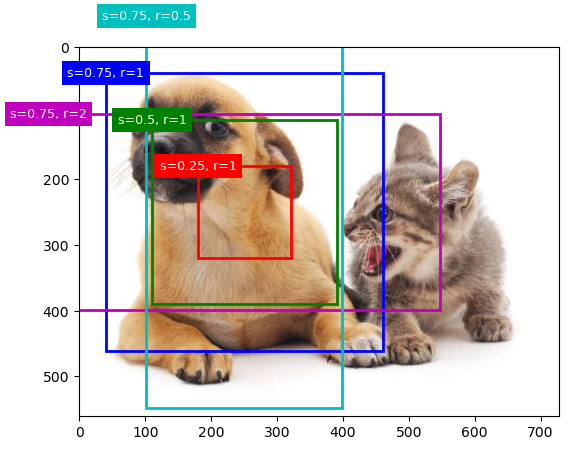

In [61]:
import matplotlib.pyplot as plt
# 读取图像
img = plt.imread('../img/catdog.jpg')
h, w = img.shape[:2]
print(h, w)

# 生成锚框
picture = torch.rand(size=(1, 3, h, w))
# (左上角x, 左上角y, 右下角x, 右下角y)归一化坐标
anchor_logic = anchor_generator(picture, sizes=[0.75, 0.5, 0.25], ratios=[1, 2, 0.5])
print(anchor_logic.shape) 
# m+n-1=3+3-1=5
anchor_logic = anchor_logic.reshape((h, w, -1, 4))
print(anchor_logic.shape)

# 选取一个中心点
# 把这个中心点的所有锚框从归一化坐标转换为实际的像素坐标
print(anchor_logic[250,250,:,:])
anchor = anchor_logic[250,250,:,:] * torch.tensor((w, h, w, h))
print(anchor)

# 显示背景图像
fig,axes = plt.subplots(1,1)
axes.imshow(img)

# 显示锚框
show_boxes(axes, anchor, labels=['s=0.75, r=1', 's=0.5, r=1', 's=0.25, r=1', 's=0.75, r=2', 's=0.75, r=0.5'])


# 二、交并比（IoU）



我们刚刚提到某个锚框“较好地”覆盖了图像中的狗。
如果已知目标的真实边界框，那么这里的“好”该如何如何量化呢？
直观地说，可以衡量锚框和真实边界框之间的相似性。
*杰卡德系数*（Jaccard）可以衡量两组之间的相似性。
给定集合$\mathcal{A}$和$\mathcal{B}$，他们的杰卡德系数是他们交集的大小除以他们并集的大小：

$$J(\mathcal{A},\mathcal{B}) = \frac{\left|\mathcal{A} \cap \mathcal{B}\right|}{\left| \mathcal{A} \cup \mathcal{B}\right|}.$$

事实上，我们可以将任何边界框的像素区域视为一组像素。通
过这种方式，我们可以通过其像素集的杰卡德系数来测量两个边界框的相似性。
对于两个边界框，它们的杰卡德系数通常称为*交并比*（intersection over union，IoU），即两个边界框相交面积与相并面积之比，如 :numref:`fig_iou`所示。
交并比的取值范围在0和1之间：0表示两个边界框无重合像素，1表示两个边界框完全重合。

![交并比是两个边界框相交面积与相并面积之比。](../img/iou.svg)
:label:`fig_iou`

接下来部分将使用交并比来衡量锚框和真实边界框之间、以及不同锚框之间的相似度。
给定两个锚框或边界框的列表，以下`box_iou`函数将在这两个列表中计算它们成对的交并比。


In [62]:

# shape(box数量，4):[xmin, ymin, xmax, ymax]
def box_iou(boxes1, boxes2):
 
    # 定一个内部函数：计算边界框的面积
    box_area = lambda boxes: ((boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1]))

    # shape(box数量，)
    areas1 = box_area(boxes1)
    # shape(box数量，)
    areas2 = box_area(boxes2)


    # None 在 PyTorch/NumPy 索引中等同于 unsqueeze 操作，它在指定位置插入一个大小为 1 的新维度。
    # (N,1,2) (1,M,2) -> (N,M,2)
    # 排列组合=N*M组(左上内部xy坐标)
    inter_upperlefts = torch.max(boxes1[:, None, :2], boxes2[:, :2]) # 内部顶点
    # 排列组合=N*M组(右下内部xy坐标)
    inter_lowerrights = torch.min(boxes1[:, None, 2:], boxes2[:, 2:]) # 内部顶点
    # 计算交集区域的宽度和高度
    # .clamp(min=0) 将所有负值截断为0
    # 这一步非常重要，因为当两个边界框没有交集时
    # inter_lowerrights - inter_upperlefts 可能会产生负值
    # 排列组合=N*M组(交集长宽wh)
    inters = (inter_lowerrights - inter_upperlefts).clamp(min=0)
    inter_w = inters[:, :, 0]
    inter_h = inters[:, :, 1]
    # 排列组合=N*M组(交集面积)
    inter_areas = inter_w * inter_h
    # ------------------------------------------------- # 

    # 计算并集区域的面积
    # 这里用到广播
    # areas1[N,1] + areas2[1,M] = sum[N,M]
    # inter_areas[N,M]
    # union_areas[N,M]
    union_areas = areas1[:, None] + areas2 - inter_areas
    # 输出(N,M)
    return inter_areas / union_areas

# 三、创造训练样本-标签

[原始图片] 
    ↓
[ CNN 骨干网络 (Backbone) ]  <--- 这里全是卷积操作，提取特征
    ↓
[ 特征图 (Feature Map) ]     <--- 每个点对应原图的一个区域
    ↓
[ 生成锚框 (Anchors) ]       <--- 在每个特征点上预设几个不同大小的框
    ↓
[ CNN 头部网络 (Heads) ]     <--- 又是卷积层/全连接层
    ├──> 分类分支：预测每个锚框的类别 (是猫吗？)
    └──> 回归分支：预测每个锚框的偏移量 (怎么微调？)
    ↓
[ 最终检测结果 ]

### 多任务学习 (Multi-task Learning)
目标检测是一个典型的**多任务学习**问题。模型在一个共享的特征提取 backbone 之上，并行地执行两个子任务：
1.  分类任务(Classification)：预测锚框中物体的类别（离散值）。
2.  回归任务(Regression)：预测真实框相对于锚框的偏移量（连续值）。

这两个任务共享底层的特征表示，但拥有各自独立的损失函数（Loss Function）：
$$ Total Loss = \lambda_{cls} \cdot L_{cls} + \lambda_{reg} \cdot L_{reg} $$
其中：
*   $L_{cls}$ 是分类损失（如交叉熵）。
*   $L_{reg}$ 是回归损失（如 Smooth L1 或 IoU Loss）。
*   $\lambda$ 是平衡两个任务权重的超参数。

### 3. 容易混淆的概念
如果你听到了类似“双重监督”的说法，可能是在指以下特殊情况（但这不属于标准目标检测的定义）：
*   半监督目标检测：同时使用有标签数据和无标签数据（通过伪标签等方式），这有时会被描述为利用了两种监督信号，但通常称为“半监督”。
*   多模态监督：例如同时使用图像和文本描述来训练模型。
*   蒸馏（Distillation）：用一个大模型（教师）的输出作为监督信号来训练小模型（学生），这时确实有两层监督（Ground Truth + 教师模型），但这叫“知识蒸馏”。

### 总结
对于标准的基于锚框（Anchor-based）的目标检测：
*   学习范式：有监督学习 (Supervised Learning)。
*   任务类型：多任务学习 (Multi-task Learning)，包含分类和回归两个子任务。
*   结论：不叫“双监督”。


贪心匹配 + 可选扩展匹配
开始
│
├─ 构建 IoU 矩阵 X (n_a × n_b)
│
├─ Step 1: 找全局最大 IoU → 分配一对 (A_i, B_j)，删该行该列
│
├─ Step 2: 在剩余矩阵中重复 Step 1，直到所有真实框都被分配
│
├─ Step 3: 此时已有 n_b 个锚框被分配（每个真实框一个）
│
└─ Step 4: 对剩下 n_a - n_b 个锚框，查原始矩阵中"每行"最大 IoU，若 > 阈值，则额外分配对应的真实框

## 在训练数据中标注锚框
:label:`subsec_labeling-anchor-boxes`



在训练集中，我们将每个锚框视为一个训练样本。
为了训练目标检测模型，我们需要每个锚框的*类别*（class）和*偏移量*（offset）标签，其中前者是与锚框相关的对象的类别，后者是真实边界框相对于锚框的偏移量。
在预测时，我们为每个图像生成多个锚框，预测所有锚框的类别和偏移量，根据预测的偏移量调整它们的位置以获得预测的边界框，最后只输出符合特定条件的预测边界框。

目标检测训练集带有*真实边界框*的位置及其包围物体类别的标签。
要标记任何生成的锚框，我们可以参考分配到的最接近此锚框的真实边界框的位置和类别标签。
下文将介绍一个算法，它能够把最接近的真实边界框分配给锚框。

## [**将真实边界框分配给锚框**]：制造训练样本-标签

给定图像，假设锚框是$A_1, A_2, \ldots, A_{n_a}$，真实边界框是$B_1, B_2, \ldots, B_{n_b}$，其中$n_a \geq n_b$。
让我们定义一个矩阵$\mathbf{X} \in \mathbb{R}^{n_a \times n_b}$，其中第$i$行、第$j$列的元素$x_{ij}$是锚框$A_i$和真实边界框$B_j$的IoU。
该算法包含以下步骤。

1. 在矩阵$\mathbf{X}$中找到最大的元素，并将它的行索引和列索引分别表示为$i_1$和$j_1$。然后将真实边界框$B_{j_1}$分配给锚框$A_{i_1}$。这很直观，因为$A_{i_1}$和$B_{j_1}$是所有锚框和真实边界框配对中最相近的。在第一个分配完成后，丢弃矩阵中${i_1}^\mathrm{th}$行和${j_1}^\mathrm{th}$列中的所有元素。
1. 在矩阵$\mathbf{X}$中找到剩余元素中最大的元素，并将它的行索引和列索引分别表示为$i_2$和$j_2$。我们将真实边界框$B_{j_2}$分配给锚框$A_{i_2}$，并丢弃矩阵中${i_2}^\mathrm{th}$行和${j_2}^\mathrm{th}$列中的所有元素。
1. 此时，矩阵$\mathbf{X}$中两行和两列中的元素已被丢弃。我们继续，直到丢弃掉矩阵$\mathbf{X}$中$n_b$列中的所有元素。此时已经为这$n_b$个锚框各自分配了一个真实边界框。
1. 只遍历剩下的$n_a - n_b$个锚框。例如，给定任何锚框$A_i$，在矩阵$\mathbf{X}$的第$i^\mathrm{th}$行中找到与$A_i$的IoU最大的真实边界框$B_j$，只有当此IoU大于预定义的阈值时，才将$B_j$分配给$A_i$。

下面用一个具体的例子来说明上述算法。
如 :numref:`fig_anchor_label`（左）所示，假设矩阵$\mathbf{X}$中的最大值为$x_{23}$，我们将真实边界框$B_3$分配给锚框$A_2$。
然后，我们丢弃矩阵第2行和第3列中的所有元素，在剩余元素（阴影区域）中找到最大的$x_{71}$，然后将真实边界框$B_1$分配给锚框$A_7$。
接下来，如 :numref:`fig_anchor_label`（中）所示，丢弃矩阵第7行和第1列中的所有元素，在剩余元素（阴影区域）中找到最大的$x_{54}$，然后将真实边界框$B_4$分配给锚框$A_5$。
最后，如 :numref:`fig_anchor_label`（右）所示，丢弃矩阵第5行和第4列中的所有元素，在剩余元素（阴影区域）中找到最大的$x_{92}$，然后将真实边界框$B_2$分配给锚框$A_9$。
之后，我们只需要遍历剩余的锚框$A_1, A_3, A_4, A_6, A_8$，然后根据阈值确定是否为它们分配真实边界框。

![将真实边界框分配给锚框。](../img/anchor-label.svg)
:label:`fig_anchor_label`

此算法在下面的`assign_anchor_to_bbox`函数中实现。


In [63]:
# 将最接近的真实边界框分配给锚框
# ground_truth(NGT,4):(xmin,ymin,xmax,ymax)
# anchors(NAC,4):(xmin,ymin,xmax,ymax)
def assign_anchor_to_bbox(ground_truth, anchors, device, iou_threshold=0.5):
    """将最接近的真实边界框分配给锚框
    参数:
        ground_truth: 真实边界框，形状为 (NGT, 4)
        anchors: 锚框，形状为 (NAC, 4)
        device: 计算设备（如 'cpu' 或 'cuda'）
        iou_threshold: IoU 阈值，用于判断是否分配真实边界框，默认为 0.5
    返回:
        anchors_bbox_map: 每个锚框分配到的真实边界框索引，形状为 (NAC,)
    """

    # 候选锚框数量
    num_gt_boxes = ground_truth.shape[0]
    # 真实锚框数量
    num_anchors = anchors.shape[0]

    # 计算交并比
    # 位于第i行和第j列的元素x_ij是锚框i和真实边界框j的IoU
    # jaccard(num_anchors,num_gt_boxes)
    jaccard = box_iou(anchors, ground_truth)
    # 创建一个全为-1的张量，用于存储每个锚框分配到的真实边界框索引
    # anchors_bbox_map(NAC,):-1表示未分配
    anchors_bbox_map = torch.full((num_anchors,), -1, dtype=torch.long, device=device)

    # 找每行最大IoU
    # 每行最大值:max_ious(num_anchors,)
    # 每行最大值的列索引:indices(num_anchors,)：对应的真实边索引
    max_ious, indices = torch.max(jaccard, dim=1)

    # 从Max IoU中筛选出正样本Positive IoU
    # max_ious >= iou_threshold:从选出来的最大值里筛选出IoU大于阈值的锚框索引，作为正样本
    # torch.nonzero():返回非零元素(正样本)的索引,返回值是二维张量，所以要reshape(-1)转换为一维张量
    # num_positive:此时正样本数量:max_ious >= iou_threshold的元素数量
    # anc_i(num_positive,):IoU矩阵的行索引，对应锚框索引
    anc_idx = torch.nonzero(max_ious >= iou_threshold).reshape(-1) # 哪些行此时是正样本
    # box_idx(num_positive,):IoU矩阵的列索引，对应真实边界框索引
    box_idx = indices[max_ious >= iou_threshold]

    # 先执行第4步：从每行中选出最大的IoU对应的真实边界框(列)，绑定当当前锚框(行)
    anchors_bbox_map[anc_idx] = box_idx



    # ------------------------------------------------------- #

    # 执行第123步：从jaccard矩阵中选出最大IoU值的索引，做行列绑定，并删除行列
    # 轮询列轮，把所有真实边界框都分配给锚框
    for _ in range(num_gt_boxes):
        # 每轮从IoU矩阵(num_anchors,num_gt_boxes)中找到最大IoU值的索引
        # torch.argmax 默认将输入张量展平成一维，再返回最大值的“扁平”索引
        # 例如 jaccard 形状为 (num_anchors, num_gt_boxes)，则 max_idx 是 0 到 num_anchors*num_gt_boxes-1 的整数
        max_idx = torch.argmax(jaccard) 

        # 定位最大IoU值对应的锚框索引(行索引)
        anc_idx = (max_idx / num_gt_boxes).long()
        # 定位最大IoU值对应的真实边界索引(列索引)
        box_idx = (max_idx % num_gt_boxes).long()

        # 第二次映射：确保每个真实边界框至少有一个锚框负责预测（保障召回）
        # 即使某个真实边界框和所有锚框的 IoU 都 < 0.5，也要强制将它分配给 IoU 最大的那个锚框。
        # 这是为了防止某些小目标或特殊形状的目标完全“漏掉”，没有锚框负责预测它，从而导致训练时无法学习到这些目标。
        # 第二次映射强制一对一绑定，即使 IoU 较低，也要保证每个 GT 有“专属 anchor”用于回归学习。
        # 因此，第二次映射覆盖第一次的结果，是合理的策略调整，目的是提升召回率（recall）。
        # 建立锚框索引(行索引)与真实边界框索引(列索引)的映射关系
        anchors_bbox_map[anc_idx] = box_idx

        # 清楚当前行和列
        jaccard[:, box_idx] = torch.full((num_anchors,), -1)
        jaccard[anc_idx, :] = torch.full((num_gt_boxes,), -1)
    # 输出(NAC,):[目标,目标,目标]
    return anchors_bbox_map

### 标记类别和偏移量

🎯 背景知识简要回顾：

在目标检测任务中，我们通常会预设一些锚框（Anchor Boxes），这些是不同尺度和比例的候选框，覆盖图像的不同区域。然后，模型需要学习：

- 每个锚框属于哪个类别？
- 这个锚框应该如何调整（偏移），才能更接近真实的物体边界框？

这就引出了“标记类别和偏移量”。

现在我们可以为每个锚框标记类别和偏移量了。
假设一个锚框$A$被分配了一个真实边界框$B$。
一方面，锚框$A$的类别将被标记为与$B$相同。
另一方面，锚框$A$的偏移量将根据$B$和$A$中心坐标的相对位置以及这两个框的相对大小进行标记。
鉴于数据集内不同的框的位置和大小不同，我们可以对那些相对位置和大小应用变换，使其获得分布更均匀且易于拟合的偏移量。
这里介绍一种常见的变换。

给定框$A$和$B$，中心坐标分别为$(x_a, y_a)$和$(x_b, y_b)$，宽度分别为$w_a$和$w_b$，高度分别为$h_a$和$h_b$，可以将$A$的偏移量标记为：

$$\left( \frac{ \frac{x_b - x_a}{w_a} - \mu_x }{\sigma_x},
\frac{ \frac{y_b - y_a}{h_a} - \mu_y }{\sigma_y},
\frac{ \log \frac{w_b}{w_a} - \mu_w }{\sigma_w},
\frac{ \log \frac{h_b}{h_a} - \mu_h }{\sigma_h}\right),$$

其中常量的默认值为 $\mu_x = \mu_y = \mu_w = \mu_h = 0, \sigma_x=\sigma_y=0.1$ ， $\sigma_w=\sigma_h=0.2$。
这种转换在下面的 `offset_boxes` 函数中实现。


In [64]:
# 使用的是中心点坐标
def offset_boxes(anchors, gt_boxes):
    # anchors: [N, 4] -> (xa, ya, wa, ha)
    # gt_boxes: [N, 4] -> (xb, yb, wb, hb)

    eps = 1e-6

    # 归一化
    dx = (gt_boxes[:, 0] - anchors[:, 0]) / anchors[:, 2]
    dy = (gt_boxes[:, 1] - anchors[:, 1]) / anchors[:, 3]
    dw = torch.log(eps + gt_boxes[:, 2] / anchors[:, 2])
    dh = torch.log(eps + gt_boxes[:, 3] / anchors[:, 3])

    # 标准化
    dx = (dx - 0) / 0.1
    dy = (dy - 0) / 0.1
    dw = (dw - 0) / 0.2
    dh = (dh - 0) / 0.2

    # [N, 4] -> (dx, dy, dw, dh)
    return torch.stack([dx, dy, dw, dh], dim=1)

In [65]:
# 求锚框和真实边界框的偏移量
# anchors(NAC,4):(xmin, ymin, xmax, ymax)
# assigned_bboxes(NAC,4):(xmin, ymin, xmax, ymax)
def offset_boxes(anchors, assigned_bboxes, eps=1e-6):

    # 一、将锚框从角点格式转换为中心点格式
    # c_anc: (NAC, 4):(x, y, w, h)
    # c_assigned_bb: (NAC, 4):(x, y, w, h)
    c_anc = d2l.box_corner_to_center(anchors)
    c_assigned_bb = d2l.box_corner_to_center(assigned_bboxes)

    # 二、归一化(中心点和宽高的偏移)
    # offset_xy(NAC, 2):(dx, dy)
    # offset_wh(NAC, 2):(dw, dh)
    offset_xy = (c_assigned_bb[:, :2] - c_anc[:, :2]) / c_anc[:, 2:]
    offset_wh = torch.log(eps + c_assigned_bb[:, 2:] / c_anc[:, 2:])

    # 三、标准化(中心点和宽高的偏移)
    # offset_xy(NAC, 2):(tx, ty)
    # offset_wh(NAC, 2):(tw, th)
    offset_xy = offset_xy * 10
    offset_wh = offset_wh * 5

    # 四、拼接中心点偏移和宽高偏移，形成最终偏移量张量
    # offset(NAC, 4):(tx, ty, tw, th)
    offset = torch.cat([offset_xy, offset_wh], axis=1)
    return offset

如果一个锚框没有被分配真实边界框，我们只需将锚框的类别标记为*背景*（background）。  
因为背景也是一个类别，也需要被模型学习。  
背景类别的锚框通常被称为*负类*锚框，其余的被称为*正类*锚框。
我们使用真实边界框（`labels`参数）实现以下`multibox_target`函数，来[**标记锚框的类别和偏移量**]（`anchors`参数）。
此函数将背景类别的索引设置为零，然后将新类别的整数索引递增一。


In [66]:
'''
标记锚框
'''
# anchors(1,NAC,4)：一个样本中所有锚框坐标
# labels(B,NGT,5):(class, xmin,ymin,xmax,ymax)
# labels 传入的是批次样本的真实边界框标签和坐标
# 而 anchors 传入的是单个样本的锚框集合。
def multibox_target(anchors, labels):
    """使用真实边界框标记锚框"""
    # B
    batch_size = labels.shape[0]
    # anchors(NAC,4)：一个样本中所有锚框坐标
    anchors = anchors.squeeze(0)
    # NAC
    num_anchors = anchors.shape[0]
    device = anchors.device
    

    # 存储每个样本中所有锚框是否对应真实边界框的掩码
    list_assigned_mask = [] 
    # 存储每个样本中所有锚框与真实边界框的偏移量
    list_assigned_offset = []
    # 存储每个样本中所有锚框的类别标签
    list_assigned_classes = []
    
    # 一个样本的所有锚框和真实边界框的偏移量
    for i in range(batch_size):
        # labels(B,NGT,5)
        # label(NGT,5)
        label = labels[i, :, :]
        classes = label[:, 0].long()
        boxes = label[:, 1:]

        # label[:,1:]:(NGT,4):(xmin,ymin,xmax,ymax)
        # anchors(NAC,4):(xmin,ymin,xmax,ymax)
        # anchors_bbox_map(NAC):每个锚框对应的真实边界框索引
        anchors_bbox_map = assign_anchor_to_bbox(boxes, anchors, device)


        # 创建类标签和分配的边界框坐标存储空间
        # class_labels(NAC):每个锚框的类别标签
        # assigned_bb(NAC,4):每个锚框的真实边界框坐标
              # 用来做掩码
        assigned_classes = torch.zeros(num_anchors, dtype=torch.long, device=device)          # 用来做分类
        assigned_bboxes = torch.zeros((num_anchors, 4), dtype=torch.float32, device=device)   # 用来做回归
        

        # bind大矩阵(anchors_bbox_map的稀疏矩阵)
        # * * * * * 
        # * * * * *
        # * * * * *
        # * * * * *
        # * * * * *
        # * * * * *
        # * * * * *
        # * * * * *
        # * * * * *
        # * * * * *
        # * * * * *
        # * * * * *



        # 找出正样本的行
        assigned_mask = (anchors_bbox_map >= 0).long()
        row = torch.nonzero(assigned_mask).reshape(-1)
        col = anchors_bbox_map[row]
    
        # 0-bg, 1-c1, 2-c2, ...
        assigned_classes[row] = classes[col] + 1
        assigned_bboxes[row] = boxes[col]
        assigned_offset = offset_boxes(anchors, assigned_bboxes) * assigned_mask.unsqueeze(-1)


  
    
        # 拼接本batch所有样本的结果
        # bbox_mask.reshape(-1):(4*NAC,):(1,1,1,1,0,0,0,0,1,1,1,1,...)
        list_assigned_mask.append(assigned_mask.reshape(-1))
        # offset.reshape(-1):(4*NAC,):(tx1,ty1,tw1, th1, tx2, ty2, tw2, th2, ...)
        list_assigned_offset.append(assigned_offset)
        # class_labels(NAC,):(c1,c2,c3,0,0,0,c4,c5,...)
        list_assigned_classes.append(assigned_classes)

    # 压缩本batch所有样本的结果
    # batch_assigned_offset(B,4*NAC):(tx1,ty1,tw1, th1, tx2, ty2, tw2, th2, ...)
    batch_assigned_offset = torch.stack(list_assigned_offset, dim=0)
    # batch_assigned_mask(B,4*NAC):(1,1,1,1,0,0,0,0,1,1,1,1,...)
    batch_assigned_mask = torch.stack(list_assigned_mask, dim=0)
    # batch_assigned_classes(B,NAC):(c1,c2,c3,0,0,0,c4,c5,...)
    batch_assigned_classes = torch.stack(list_assigned_classes, dim=0)
    # 每个锚框是否对应真实边界框的掩码
    # 偏移量：batch_assigned_offset(B,4*NAC):(tx1,ty1,tw1, th1, tx2, ty2, tw2, th2, ...)
    # 掩码：batch_assigned_mask(B,4*NAC):(1,1,1,1,0,0,0,0,1,1,1,1,...)
    # 类别：batch_assigned_classes(B,NAC):(c1,c2,c3,0,0,0,c4,c5,...)
    return (batch_assigned_offset, batch_assigned_mask, batch_assigned_classes)


### 一个例子

下面通过一个具体的例子来说明锚框标签。
我们已经为加载图像中的狗和猫定义了真实边界框，其中第一个元素是类别（0代表狗，1代表猫），其余四个元素是左上角和右下角的$(x, y)$轴坐标（范围介于0和1之间）。
我们还构建了五个锚框，用左上角和右下角的坐标进行标记：$A_0, \ldots, A_4$（索引从0开始）。
然后我们[**在图像中绘制这些真实边界框和锚框**]。


tensor([[[-0.00e+00, -0.00e+00, -0.00e+00, -0.00e+00],
         [ 1.40e+00,  1.00e+01,  2.59e+00,  7.18e+00],
         [-1.20e+00,  2.69e-01,  1.68e+00, -1.57e+00],
         [-0.00e+00, -0.00e+00, -0.00e+00, -0.00e+00],
         [-5.71e-01, -1.00e+00,  4.17e-06,  6.26e-01]]])
tensor([[0, 1, 1, 0, 1]])
tensor([[0, 1, 2, 0, 2]])


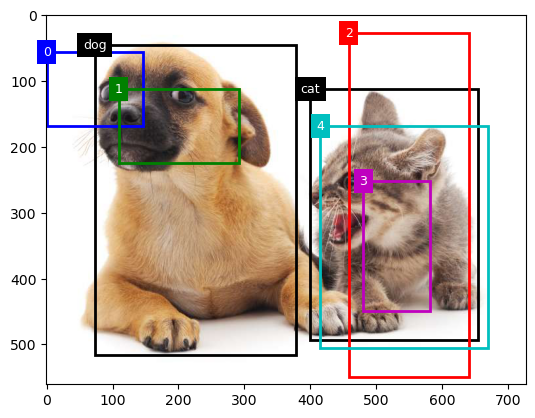

In [67]:
import matplotlib.pyplot as plt
# ground_truth(B,5):(class_index,xmin,ymin,xmax,ymax)
ground_truth = torch.tensor([[0, 0.1, 0.08, 0.52, 0.92],
                             [1, 0.55, 0.2, 0.9, 0.88]])
# anchors(NAC,4):(xmin,ymin,xmax,ymax)
anchors = torch.tensor([[0, 0.1, 0.2, 0.3], 
                        [0.15, 0.2, 0.4, 0.4],
                        [0.63, 0.05, 0.88, 0.98],
                        [0.66, 0.45, 0.8, 0.8],
                        [0.57, 0.3, 0.92, 0.9]])

fig = plt.imshow(img)
bbox_scale = torch.tensor((w, h, w, h))
# 乘以 bbox_scale 将归一化坐标转换为实际的像素坐标
show_boxes(fig.axes, ground_truth[:, 1:] * bbox_scale, ['dog', 'cat'], 'k')
show_boxes(fig.axes, anchors * bbox_scale, ['0', '1', '2', '3', '4'])

# 提升维度，将锚框和真实边界框转换为批量格式
anchors = anchors.unsqueeze(dim=0)
ground_truth = ground_truth.unsqueeze(dim=0)

labels = multibox_target(anchors, ground_truth)
print(labels[0])
print(labels[1])
print(labels[2])


让我们根据图像中的锚框和真实边界框的位置来分析下面返回的类别标签。
首先，在所有的锚框和真实边界框配对中，锚框$A_4$与猫的真实边界框的IoU是最大的。
因此，$A_4$的类别被标记为猫。
去除包含$A_4$或猫的真实边界框的配对，在剩下的配对中，锚框$A_1$和狗的真实边界框有最大的IoU。
因此，$A_1$的类别被标记为狗。
接下来，我们需要遍历剩下的三个未标记的锚框：$A_0$、$A_2$和$A_3$。
对于$A_0$，与其拥有最大IoU的真实边界框的类别是狗，但IoU低于预定义的阈值（0.5），因此该类别被标记为背景；
对于$A_2$，与其拥有最大IoU的真实边界框的类别是猫，IoU超过阈值，所以类别被标记为猫；
对于$A_3$，与其拥有最大IoU的真实边界框的类别是猫，但值低于阈值，因此该类别被标记为背景。
返回的第二个元素是掩码（mask）变量，形状为（批量大小*锚框数*4）。
掩码变量中的元素与每个锚框的4个偏移量一一对应。
由于我们不关心对背景的检测，负类的偏移量不应影响目标函数。
通过元素乘法，掩码变量中的零将在计算目标函数之前过滤掉负类偏移量。


# 三、nms非极大值抑制

在预测时，我们先为图像生成多个锚框，再为这些锚框一一预测类别和偏移量。
一个*预测好的边界框*则根据其中某个带有预测偏移量的锚框而生成。
下面我们实现了`offset_inverse`函数，该函数将锚框和偏移量预测作为输入，并[**应用逆偏移变换来返回预测的边界框坐标**]。


你提的问题非常好，触及了目标检测中“锚框机制”和“预测解码”的核心逻辑。我们来一步步拆解：

---

## 🎯 你的疑问本质：
> “之前算偏移量是锚框和真实标签（ground truth）之间的偏移，那现在用这个偏移量 + 锚框反推回去，得到的不应该是‘真实框’吗？为什么叫‘预测框’？”

✅ **关键点在于：这里的 offset_preds 不是来自真实标签，而是模型预测出来的！**

---

## 🔍 详细解释：

### 1️⃣ 训练阶段 vs 预测阶段

- **训练时**：
  - 我们有真实标注框（ground truth boxes）。
  - 对每个锚框（anchor），计算它与最匹配的真实框之间的“偏移量”（offsets）——这是作为**监督信号（label）**。
  - 模型学习的是：**给定一个锚框，输出它应该调整多少才能接近真实框**。
  - 所以训练时的 `offset_labels` = f(anchor, gt_box)

- **预测时（推理阶段）**：
  - 没有真实框！只有输入图像 → 生成锚框 → 模型对每个锚框预测两个东西：
    - 类别概率（class scores）
    - 偏移量（offset predictions）→ 这就是图中的 `offset_preds`
  - 然后我们用这些**预测的偏移量**去“修正”锚框，得到最终的预测边界框。

所以：

> ✅ `offset_inverse(anchors, offset_preds)` 中的 `offset_preds` 是**模型预测值**，不是真实值！

因此，逆运算出来的是“根据模型预测调整后的框”，也就是**预测框（predicted bbox）**，而不是真实框。

---


In [68]:
# 把偏移量施加到锚框上，得到预测框
def offset_inverse(anchors, offsets):
    """
    将偏移量还原为边界框坐标。
    
    Args:
        anchors: Tensor [N, 4], 格式 (xa, ya, wa, ha)
        offsets: Tensor [N, 4], 格式 (dx, dy, dw, dh) (已标准化)
        
    Returns:
        gt_boxes: Tensor [N, 4], 格式 (xb, yb, wb, hb)
    """
    # 确保输入是浮点数以防整数除法问题
    anchors = anchors.float()
    offsets = offsets.float()

    # 1. 逆向标准化 (Denormalization)
    # 原逻辑: norm_val = raw_val / std
    # 逆逻辑: raw_val = norm_val * std
    stds = torch.tensor([0.1, 0.1, 0.2, 0.2], device=anchors.device, dtype=anchors.dtype)
    
    # 提取并还原原始偏移量
    dx = offsets[:, 0] * stds[0]
    dy = offsets[:, 1] * stds[1]
    dw = offsets[:, 2] * stds[2]
    dh = offsets[:, 3] * stds[3]

    # 提取锚框参数
    xa = anchors[:, 0]
    ya = anchors[:, 1]
    wa = anchors[:, 2]
    ha = anchors[:, 3]

    # 2. 逆向计算真实框坐标
    xb = xa + dx * wa
    yb = ya + dy * ha
    

    # 注意：原函数中有 eps = 1e-6 在 log 内。
    # 严格数学逆运算是 wa * (exp(dw) - eps)，但在深度学习实践中，
    # 由于 eps 极小且 exp(dw) 通常远大于 eps，通常直接写作 wa * exp(dw)。
    # 这里为了数值稳定且符合常规检测头解码逻辑，使用 exp。
    wb = wa * torch.exp(dw)
    hb = ha * torch.exp(dh)

    # 堆叠返回 [N, 4] -> (xb, yb, wb, hb)
    gt_boxes = torch.stack([xb, yb, wb, hb], dim=1)
    
    return gt_boxes


当有许多锚框时，可能会输出许多相似的具有明显重叠的预测边界框，都围绕着同一目标。
为了简化输出，我们可以使用*非极大值抑制*（non-maximum suppression，NMS）合并属于同一目标的类似的预测边界框。

以下是非极大值抑制的工作原理。
对于一个预测边界框$B$，目标检测模型会计算每个类别的预测概率。
假设最大的预测概率为$p$，则该概率所对应的类别$B$即为预测的类别。
具体来说，我们将$p$称为预测边界框$B$的*置信度*（confidence）。
在同一张图像中，所有预测的非背景边界框都按置信度降序排序，以生成列表$L$。然后我们通过以下步骤操作排序列表$L$。

1. 从$L$中选取置信度最高的预测边界框$B_1$作为基准，然后将所有与$B_1$的IoU超过预定阈值$\epsilon$的非基准预测边界框从$L$中移除。这时，$L$保留了置信度最高的预测边界框，去除了与其太过相似的其他预测边界框。简而言之，那些具有*非极大值*置信度的边界框被*抑制*了。
1. 从$L$中选取置信度第二高的预测边界框$B_2$作为又一个基准，然后将所有与$B_2$的IoU大于$\epsilon$的非基准预测边界框从$L$中移除。
1. 重复上述过程，直到$L$中的所有预测边界框都曾被用作基准。此时，$L$中任意一对预测边界框的IoU都小于阈值$\epsilon$；因此，没有一对边界框过于相似。
1. 输出列表$L$中的所有预测边界框。

[**以下`nms`函数按降序对置信度进行排序并返回其索引**]。


在标准的 NMS 算法实现中，**我们并不是直接对“所有类别混合在一起”的列表 $L$ 进行排序和抑制**。

正确的做法是：**按类别分组（Group by Class），对每一类单独执行 NMS。**

---

### 🚫 为什么不能混在一起做？

如果把所有类别的框混在一个列表 $L$ 里排序并计算 IoU，会出现严重的逻辑错误：

1.  **IoU 无意义**：
    *   假设有一个高分的“猫”框（置信度 0.9）和一个低分的“狗”框（置信度 0.6）。
    *   如果它们位置重叠（比如猫趴在狗身上），计算出的 IoU 可能很高（>0.5）。
    *   如果混在一起做 NMS，高分的“猫”框会把低分的“狗”框给**误删**掉！
    *   **结果**：图中的狗消失了，只剩下了猫。这显然是不对的，因为猫和狗是两个不同的目标，应该共存。

2.  **语义冲突**：
    *   NMS 的目的是去除“重复检测同一个目标”的框。
    *   “猫”的框和“狗”的框代表不同的语义对象，即使它们重叠，也不是“重复”，而是“两个物体靠得很近”。

---

### ✅ 正确的标准流程（Class-Aware NMS）

在实际的目标检测代码（如 YOLO, Faster R-CNN, SSD, Detectron2, MMDetection）中，NMS 的执行步骤如下：

#### 第 1 步：过滤与分类
遍历模型输出的所有预测框：
- 去掉背景类（background）。
- 去掉置信度低于阈值（如 0.3）的框。
- **关键点**：将剩余的框**按预测类别分开**。
  - 列表 $L_{cat}$ = 所有预测为“猫”的框
  - 列表 $L_{dog}$ = 所有预测为“狗”的框
  - 列表 $L_{person}$ = 所有预测为“人”的框
  - ...

#### 第 2 步：分别排序
对每一个类别的列表单独按置信度降序排序：
- $L_{cat}$ 排序 $\rightarrow$ [猫框A(0.9), 猫框B(0.8), ...]
- $L_{dog}$ 排序 $\rightarrow$ [狗框X(0.85), 狗框Y(0.6), ...]

#### 第 3 步：分别执行 NMS
**独立地**对每个类别的列表运行 NMS 算法：
- 在 $L_{cat}$ 内部：如果猫框A和猫框B重叠度高，删掉分低的。
- 在 $L_{dog}$ 内部：如果狗框X和狗框Y重叠度高，删掉分低的。
- **注意**：计算 IoU 时，只比较同类别的框。**绝不跨类别计算 IoU**。

#### 第 4 步：合并结果
将所有类别经过 NMS 筛选后留下的框，合并成最终的输出列表。

---

### 💻 伪代码示例

```python
final_results = []

# 假设 all_boxes 包含所有框，结构为：[x1, y1, x2, y2, score, class_id]
classes = unique(all_boxes[:, 5]) # 获取所有出现的类别ID

for cls in classes:
    # 1. 提取当前类别的所有框
    cls_boxes = all_boxes[all_boxes[:, 5] == cls]
    
    # 2. 按置信度排序 (score 是第4列)
    cls_boxes = cls_boxes[cls_boxes[:, 4].argsort()[::-1]]
    
    # 3. 对该类别单独执行 NMS
    # keep_indices 是保留下来的框的索引
    keep_indices = nms(cls_boxes[:, :4], cls_boxes[:, 4], iou_threshold=0.5)
    
    # 4. 将保留的框加入最终结果
    final_results.append(cls_boxes[keep_indices])

# 合并所有类别的结果
output = concatenate(final_results)
```

---

例如：在一张图中有两只猫，但模型可能预测出 10个 都包围同一只猫的边框。这些边框之间有很高的重叠度（IoU），但我们只需要保留一个最准确的框。

NMS 就是用来去除冗余、重复的边界框，只保留置信度最高且不与其他框过度重叠的框。

🧠 NMS 的核心思想
- 所有预测框按置信度（confidence score）从高到低排序。
- 选置信度最高的框作为“基准框”。
- 删除所有与该基准框 IoU > 阈值（如0.5） 的其他框（因为它们太相似了）。
- 重复上述过程，直到所有框都被处理完。

最终结果：每类目标只保留几个最合适的框（通常每个目标仅保留一个）。

In [69]:
# 非极大值抑制
# boxes: (N, 4)  N个边界框，每个框4个坐标
# scores: (N,)   每个边界框的置信度得分
# iou_threshold: 抑制阈值
def nms(boxes, scores, iou_threshold):
    # 对预测边界框的置信度进行排序
    # B: (N,)  按置信度降序排列的索引:从高到低
    B = torch.argsort(scores, dim=-1, descending=True)  
    keep = []  # 保留预测边界框的指标

    # NMS
    while B.numel() > 0:# 当待处理框数量大于0时，继续处理
        # 本轮最高置信框索引
        i = B[0]
        # 保留当前最高置信框索引
        keep.append(i)
        # 如果只剩一个框，直接跳出循环
        if B.numel() == 1: 
            break

        max_index = i
        rest_indices = B[1:]
        
        # 取出当前最高置信框
        current_box = boxes[max_index, :].reshape(-1, 4)          # (1, 4)
        # 取出剩余待比较框
        rest_boxes = boxes[rest_indices, :].reshape(-1, 4)       # (N-1, 4)
        # 计算两两 IoU(1,N-1)->(N-1,)
        # (0,1,2,3,4)
        # (0-1,0-2,0-3,0-4)
        iou = box_iou(current_box, rest_boxes).reshape(-1)  # (N-1,)
        # 筛选出 IoU 小于阈值的框自然索引
        inds = torch.nonzero(iou <= iou_threshold).reshape(-1)  # inds: (M,)  保留的索引，M <= N-1
        # 转换为总绝对索引
        inds = inds + 1
        # 下一轮参与NMS的框索引
        B = B[inds]

    return torch.tensor(keep, device=boxes.device)  # (K,)  K为最终保留的框数量


pytorch自带的nms函数

In [70]:
# from torchvision.ops import nms
# import torch

# # 假设 boxes 和 scores 已经定义
# # boxes: (N, 4) 格式为 [x1, y1, x2, y2]
# # scores: (N,)
# # iou_threshold: 标量

# keep_indices = nms(boxes, scores, iou_threshold)

# # keep_indices 是一个包含保留框索引的 Tensor (K,)
# # 你可以通过它来获取最终的框和得分：
# final_boxes = boxes[keep_indices]
# final_scores = scores[keep_indices]

我们定义以下`multibox_detection`函数来[**将非极大值抑制应用于预测边界框**]。
这里的实现有点复杂，请不要担心。我们将在实现之后，马上用一个具体的例子来展示它是如何工作的。


In [ ]:
#
def multibox_detection(pred_classes,       # cls_probs(1, NCLS, NAC)
                       offset_preds,    # offset_preds(1, NAC*4)
                       anchors,         # anchors(1, NAC, 4)
                       nms_threshold=0.5,      # 非极大值抑制的IoU阈值，高于此阈值的重复框会被抑制
                       pos_threshold=0.009999999):  # 正类置信度阈值，低于此值的预测会被视为背景
    """使用非极大值抑制来预测边界框"""
    device, batch_size = pred_classes.device, pred_classes.shape[0]
    # anchors(1, NAC, 4) -> anchors(NAC, 4)
    anchors = anchors.squeeze(0)
    num_classes, num_anchors = pred_classes.shape[1], pred_classes.shape[2]

    out = []
    for i in range(batch_size):
        # cls_prob(NCLS, NAC)
        # offset_preds[i](NAC*4)
        # reshape(-1, 4):(NAC, 4)
        # offset_pred(NAC, 4)
        cls_prob, offset_pred = pred_classes[i], offset_preds[i].reshape(-1, 4)
        # cls_prob[0] 通常表示背景类的概率
        # cls_prob[1:] 表示除了背景类之外的所有类别概率
        # torch.max 函数用于找出张量中的最大值:列
        # conf(NAC)
        # class_id(NAC)
        conf, class_id = torch.max(cls_prob[1:], dim=0)
        # 把偏移量施加到锚框上，得到预测框
        # anchors(NAC, 4)
        # offset_pred(NAC, 4)
        # predicted_bb(NAC, 4)
        predicted_bb = offset_inverse(anchors, offset_pred)
        # 非极大值抑制
        # 混合类别的 NMS:先定类别，后做NMS,不会出现同一个预测框被分配为两个类别的情况
        # 如果两个重叠很高的框，一个是“猫（0.9）”，一个是“狗（0.8）”。
        # NMS 会保留分数高的“猫”，抑制掉“狗”。
        keep = nms(predicted_bb, conf, nms_threshold)

        # 找到所有的non_keep索引，并将类设置为背景
        all_idx = torch.arange(num_anchors, dtype=torch.long, device=device)
        combined = torch.cat((keep, all_idx))
        # 比如 [0, 2, 0, 1, 2, 3] 
        # uniques ：所有唯一元素 [0, 1, 2, 3] 
        # counts ：每个唯一元素在 combined 中出现的次数 [2, 1, 2, 1] 
        uniques, counts = combined.unique(return_counts=True)
        non_keep = uniques[counts == 1]
        all_id_sorted = torch.cat((keep, non_keep))
        class_id[non_keep] = -1
        class_id = class_id[all_id_sorted]
        
        conf = conf[all_id_sorted]
        predicted_bb = predicted_bb[all_id_sorted]
        # pos_threshold是一个用于非背景预测的阈值
        below_min_idx = (conf < pos_threshold)
        class_id[below_min_idx] = -1
        conf[below_min_idx] = 1 - conf[below_min_idx]

        # class_id(NAC,1)
        # conf(NAC,1)
        # predicted_bb(NAC, 4)
        # pred_info(NAC, 6)
        pred_info = torch.cat((class_id.unsqueeze(1),
                               conf.unsqueeze(1),
                               predicted_bb), dim=1)
        out.append(pred_info)
        # out(1, NAC, 6)
    return torch.stack(out)

现在让我们[**将上述算法应用到一个带有四个锚框的具体示例中**]。
为简单起见，我们假设预测的偏移量都是零，这意味着预测的边界框即是锚框。
对于背景、狗和猫其中的每个类，我们还定义了它的预测概率。


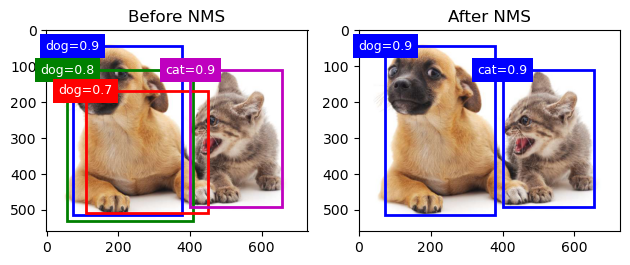

In [90]:
# anchors(NAC, 4)
# 生成锚框(手动)
anchors = torch.tensor([[0.1, 0.08, 0.52, 0.92],
                        [0.08, 0.2, 0.56, 0.95],
                        [0.15, 0.3, 0.62, 0.91], 
                        [0.55, 0.2, 0.9, 0.88]])

# 预测偏移量(手动):这里都设为0，是为了简化问题
offset_preds = torch.zeros((4, 4))

# 预测出的边界框
pred_bboxes = offset_inverse(anchors, offset_preds)


# cls_probs(NCLS, NAC)
# 预测出的类别(手动)
pred_classes = torch.tensor([[0,   0,   0,   0],  # 背景的预测概率
                          [0.9, 0.8, 0.7, 0.1],  # 狗的预测概率
                          [0.1, 0.2, 0.3, 0.9]])  # 猫的预测概率


# 读取图像
img = plt.imread('../img/catdog.jpg')
fig,axes = plt.subplots(1,2)

# 第一幅图:使用NMS之前
axes[0].imshow(img)
axes[0].set_title('Before NMS')
h, w = img.shape[:2]
box_scale = torch.tensor([w, h, w, h])

show_boxes(axes[0], pred_bboxes * box_scale,['dog=0.9', 'dog=0.8', 'dog=0.7', 'cat=0.9'])

# 第二幅图:使用NMS之后
axes[1].imshow(img)
axes[1].set_title('After NMS')

# cls_probs.unsqueeze(dim=0)(1, NCLS, NAC)
# offset_preds.unsqueeze(dim=0)(1, NAC*4)
# anchors.unsqueeze(dim=0)(1, NAC, 4)
# output(1, NAC, 6):(class_id, conf, predicted_bb)
offset_preds = offset_preds.reshape(-1) # (NAC*4)
output = multibox_detection(pred_classes.unsqueeze(dim=0),
                            offset_preds.unsqueeze(dim=0),
                            anchors.unsqueeze(dim=0),
                            nms_threshold=0.5)
# 从batch中提取第一个样本的输出
output = output[0]

for i in output.detach().numpy():
    if i[0] == -1:
        continue
    label = ('dog=', 'cat=')[int(i[0])] + str(i[1])
    show_boxes(axes[1], [torch.tensor(i[2:]) * box_scale], label)

plt.tight_layout()
plt.show()

实践中，在执行非极大值抑制前，我们甚至可以将置信度较低的预测边界框移除，从而减少此算法中的计算量。
我们也可以对非极大值抑制的输出结果进行后处理。例如，只保留置信度更高的结果作为最终输出。

## 小结

* 我们以图像的每个像素为中心生成不同形状的锚框。
* 交并比（IoU）也被称为杰卡德系数，用于衡量两个边界框的相似性。它是相交面积与相并面积的比率。
* 在训练集中，我们需要给每个锚框两种类型的标签。一个是与锚框中目标检测的类别，另一个是锚框真实相对于边界框的偏移量。
* 预测期间可以使用非极大值抑制（NMS）来移除类似的预测边界框，从而简化输出。

## 练习

1. 在`multibox_prior`函数中更改`sizes`和`ratios`的值。生成的锚框有什么变化？
1. 构建并可视化两个IoU为0.5的边界框。它们是怎样重叠的？
1. 在 :numref:`subsec_labeling-anchor-boxes`和 :numref:`subsec_predicting-bounding-boxes-nms`中修改变量`anchors`，结果如何变化？
1. 非极大值抑制是一种贪心算法，它通过*移除*来抑制预测的边界框。是否存在一种可能，被移除的一些框实际上是有用的？如何修改这个算法来柔和地抑制？可以参考Soft-NMS :cite:`Bodla.Singh.Chellappa.ea.2017`。
1. 如果非手动，非最大限度的抑制可以被学习吗？


[Discussions](https://discuss.d2l.ai/t/2946)
